In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = R:\projects_Agency_EBCI\Agency_EBCI


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [17]:
path_filename= r"..\data\test\03_06 Artem\01_222sec_112.hdf"
path_filename = r"R:\projects_FEEDBACK_QUASI\data\tests\01 Evgeny 13.03\01 calibration session.hdf"

In [18]:
from numpy import array, uint8
from h5py import File

def load_h5df(path):
    """
    Load EEG data and block metadata from an HDF5 (.h5f) file.

    Parameters
    ----------
    path : str
        Path to the HDF5 (.h5f) file.

    Returns
    -------
    data : array-like
        Signal data stored in the file.
    blocks : array-like of structured dtype [('created', '<u8'), ('received', '<u8'), ('samples', '<u4')]
        Metadata for recorded data blocks, including timestamps
        of block creation and reception, and the number of samples
        in each block.
    """
    with File(path, "r") as h5f:
        data = h5f["eeg"]["data"][:-1]
        blocks = h5f["eeg"]["blocks"][:]

    return data, blocks

In [19]:
data, blocks = load_h5df(path_filename)

In [20]:
trigger = data[:, -1]

In [21]:
def ttl2binary(ttl_signal, bit_index=0):
    """
    Decode a binary signal from a TTL channel by selecting a specific bit.

    Parameters
    ----------
    ttl_signal : array-like
        Integer TTL values.
    bit_index : int
        Bit position to decode.

    Returns
    -------
    binary_signal : array-like
        Binary (0 or 1) signal extracted from the TTL input.
    """
    ttl = array(ttl_signal, dtype=uint8)
    return ((ttl>>bit_index) & 0b1).astype(int)

def reverse_trigger(trigger):
    return 1 - trigger

def trigger_to_event_v1_1(trigger, window_size=600):
    """
    Parse a photodiode trigger signal to detect motor and rest events.

    This function scans a binary photomark signal and identifies events
    based on the magnitude of fluctuations within a sliding window. 
    It returns an array of the same length as the input trigger, where
    each element indicates the type of event at that time.

    Parameters
    ----------
    trigger : array-like
        Binary (0 or 1) signal from a photodiode, representing stimulus fluctuations.
    window_size : int, optional, default=600
        Number of samples to consider in the sliding window when detecting changes.

    Returns
    -------
    events : array-like
        Array of the same length as `trigger`, containing:
        - 0 : no event
        - 1 : motor event
        - 2 : rest event
    trigger_sum : array-like
        Array of the same length as `trigger`, 
        containing sum of its elements in window_size. 
    """

    events = np.zeros(len(trigger)) 
    
    n_motor = 0
    wait_start = True
    idx_trial_start = None
    idx_rest = None
    trigger_sum = []
    pr_v = 0
    for start_idx in range(len(trigger)):
        how_much_left = len(trigger) - window_size
        end_idx = start_idx + window_size if window_size < how_much_left else start_idx + how_much_left
        tsum = sum(trigger[start_idx:end_idx])
        trigger_sum.append(tsum)

        tsummax = max(trigger_sum[-window_size:])                   # max value for the last window_size ms
        if (pr_v == tsummax) & (tsum < pr_v):                       # if new value is smaller than previous
            if wait_start:                                         # two  bursts  -> signal of a beginning 
                wait_start = False
                idx_trial_start = start_idx
            elif not(wait_start) and (n_motor < 4):                # three bursts -> signal of a motor trial 
                n_motor += 1
                if n_motor == 4:
                    events[idx_trial_start:start_idx] = 1
                    idx_rest = start_idx
            elif not(wait_start) and (n_motor == 4):               # four bursts -> signal of a rest trial
                events[idx_rest:start_idx] = 2
                n_motor = 0
                wait_start = True

        pr_v =  tsum
    
    return events, np.asarray(trigger_sum) 

In [8]:
def parse_trigger(data_filename):
    data, _ = load_h5df(data_filename)
    signal = data[:, :-1]

    trigger = ttl2binary(data[:, -1], bit_index=0)
    trigger = reverse_trigger(trigger)
    events, _ = trigger_to_event_v1_1(trigger, window_size=600)        # 1 - motor, 2 - rest

    data_new = np.concatenate([signal, events.reshape((-1, 1))], axis=1)
    return data_new

data = parse_trigger(path_filename)

In [22]:
trigger = ttl2binary(data[:, -1], bit_index=0)
trigger = reverse_trigger(trigger)

window_size = 200
strigger = np.convolve(trigger, np.ones(window_size, dtype=int), 'valid')


start_idx = np.where((strigger == window_size) & (np.diff(strigger, prepend=0) == 1))[0].reshape((-1, 1))
end_idx = np.where((strigger == 0) & (np.diff(strigger, prepend=0) == -1))[0].reshape((-1, 1))

events = np.concatenate([start_idx, end_idx], axis=1)

In [23]:
dtrigger = np.diff(trigger)

def define_label(dtrigger, idx, buff=600, labels={1: 0, 2: 1, 3: 2}):
    dtrig = dtrigger[idx-buff:idx-10] 
    n_shifts = np.where(dtrig == 1)[0].shape[0]
    for key in labels:
        if n_shifts == key:
            return labels[key]
    return np.nan

labels = np.array([define_label(dtrigger, idx[0]) for idx in start_idx]).reshape((-1, 1))

In [24]:
palette = {
    0: "black", 
    1: "blue", 
    2: "green"
}

In [41]:
def parse_events(trigger, window_size=200):
    strigger = np.convolve(trigger, np.ones(window_size, dtype=int), 'valid')   # sum of trigger in window  
    
    start_idx = np.where((strigger == window_size) & (np.diff(strigger, prepend=0) == 1))[0].reshape((-1, 1))
    end_idx = np.where((strigger == 0) & (np.diff(strigger, prepend=0) == -1))[0].reshape((-1, 1))

    events = np.concatenate([start_idx, end_idx], axis=1)

    dtrigger = np.diff(trigger)
    labels = np.array([define_label(dtrigger, idx[0]) for idx in start_idx])

    # idxs1 = events[labels == 0]
    idxs2 = events[labels == 1]
    idxs3 = events[labels == 2]
    
    # for quasi feedback
    start_idx = (idxs2[:, 1] + 4000).reshape((-1, 1))
    end_idx = (start_idx + 8000).reshape((-1, 1))
    idxs1 = np.concatenate([start_idx, end_idx], axis=1)
    
    return idxs1, idxs2, idxs3

idxs1, idxs2, idxs3 = parse_events(trigger)
idxs1.shape, idxs2.shape, idxs3.shape

((20, 2), (20, 2), (0, 2))

(50000.0, 100000.0)

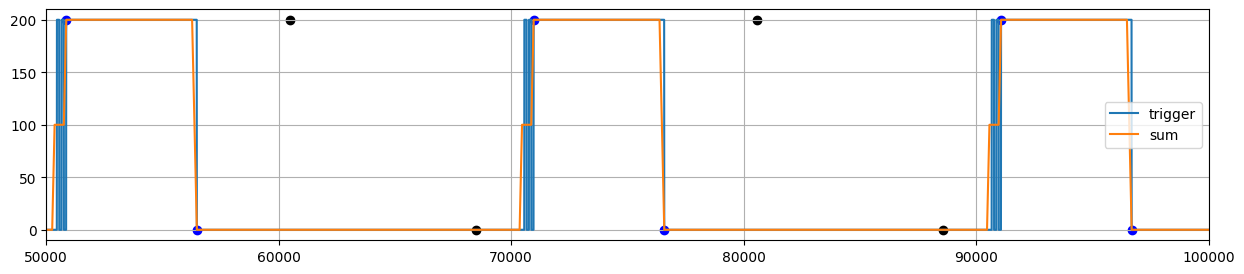

In [43]:
n = 1
fig, ax = plt.subplots(n, 1, figsize=(15, int(3*n)), sharex=True)

ax.plot(trigger * window_size, label="trigger")
ax.plot(strigger, label="sum")
# ax.plot(np.diff(strigger)  * window_size, label="sum diff", linewidth=.5)
# ax.plot(dtrigger*window_size)

for event, label in zip(events, labels):
    color = palette[label[0]]
    ax.scatter(event[0], window_size, color=color)
    ax.scatter(event[1], 0, color=color)

for idx in idxs1:
    ax.scatter(idx[0], window_size, color="black")
    ax.scatter(idx[1], 0, color="black")

ax.legend()

ax.grid()
# xrange = [start_idx[105]-2000, end_idx[105]+500] #start_idx[-1]+5000]
# ax.axvline(start_idx[105]-600)
xrange = [50000, 100000]
ax.set_xlim(xrange)

In [182]:
label

array([1])

In [112]:
np.where((strigger == 0))

(array([     0,      1,      2, ..., 400362, 400363, 400364],
       shape=(116606,)),)

In [19]:

def parse_events(trigger, window_size=600):
    trigger_sum = []
    idxs_start = []
    for start_idx in range(len(trigger)):
        how_much_left = len(trigger) - window_size
        end_idx = start_idx + window_size if window_size < how_much_left else start_idx + how_much_left
        tsum = np.sum(trigger[start_idx:end_idx])
        trigger_sum.append(tsum)

    sum_trigger = np.array(trigger_sum)
    dsumtrigger = np.diff(sum_trigger)

    trial_len = 1800
    idxs_end = np.where((sum_trigger[:-1] == 600) & (dsumtrigger == -1))[0] + 500
    idxs_start = idxs_end - trial_len
    
    photo_len = 700
    idxs_photo = idxs_start - photo_len

    mask = np.ones(len(idxs_start))    # rest
    for i, idx in enumerate(idxs_photo):
        sphoto = np.sum(trigger[idx:idxs_start[i]])
    
        if sphoto < 250:
            mask[i] = 0
        if sphoto > 300:
            mask[i] = 2

    idxs = np.concatenate([idxs_start.reshape((-1, 1)), idxs_end.reshape((-1, 1))], axis=1)
    idxs1 = idxs[mask == 0]
    idxs2 = idxs[mask == 1]
    idxs3 = idxs[mask == 2]
    
    return idxs1, idxs2, idxs3

idxs1, idxs2, idxs3 = parse_events(trigger)

In [20]:
idxs1.shape, idxs2.shape, idxs3.shape

((60, 2), (30, 2), (30, 2))

(9000.0, 40000.0)

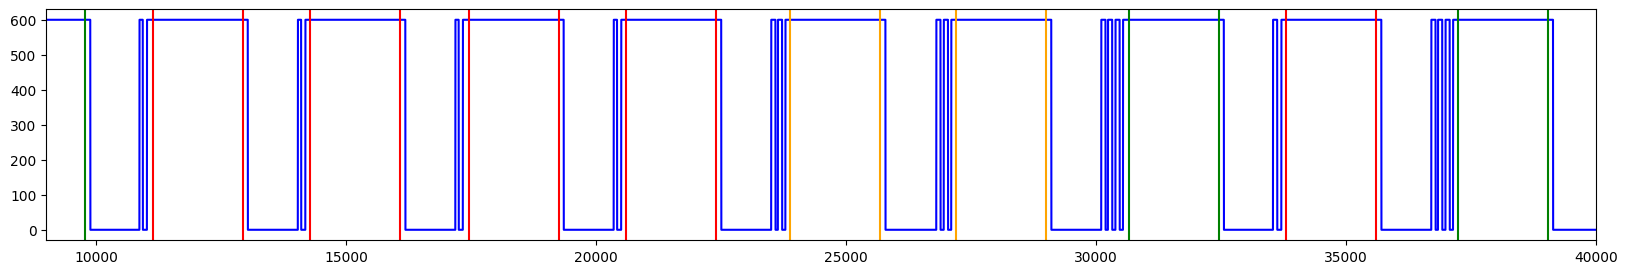

In [21]:
fig, ax= plt.subplots(1, 1, figsize=(20, 3))
ax.plot(trigger* 600, color="blue");
colors = ['red', 'orange', 'green']
for color, idxs in zip(colors, [idxs1, idxs2, idxs3]):
    for idx in idxs:
        ax.axvline(idx[0], color=color)
        ax.axvline(idx[1], color=color)
ax.set_xlim(9000, 40000) #20000)

(9000.0, 40000.0)

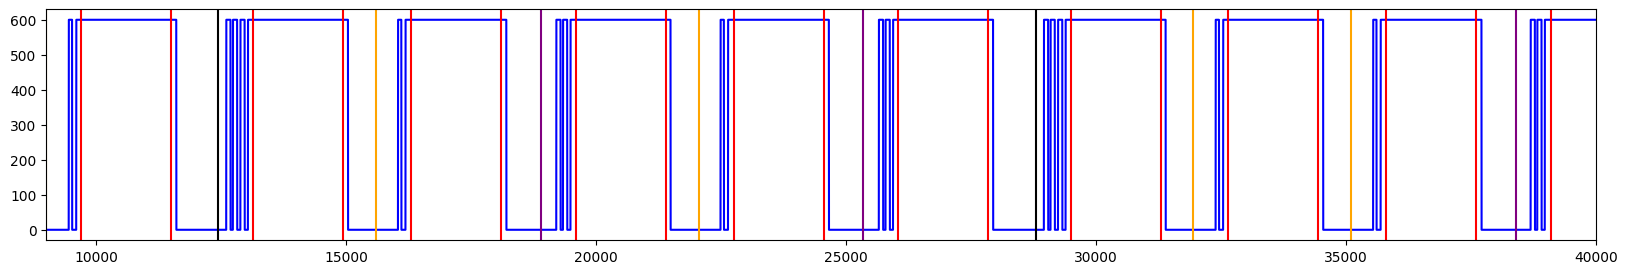

In [171]:
fig, ax= plt.subplots(1, 1, figsize=(20, 3))
ax.plot(trigger* 600, color="blue");
# ax.plot(sum_trigger, color="orange");
# ax.plot(dsumtrigger*600, color="purple")

trial_len = 1800
idxs_end = np.where((sum_trigger[:-1] == 600) & (dsumtrigger == -1))[0] + 500
idxs_start = idxs_end - trial_len

photo_len = 700
idxs_photo = idxs_start - photo_len

for idx in idxs_end:
    ax.axvline(idx, color="red") 

for idx in idxs_start:
    ax.axvline(idx, color="red")

for i, idx in enumerate(idxs_photo):
    sphoto = np.sum(trigger[idx:idxs_start[i]])
    color = "purple"
    if sphoto < 250:
        color = "orange"
    if sphoto > 300:
        color = "black"
    ax.axvline(idx, color=color)

# ax.plot(sdtrigger);
ax.set_xlim(9000, 40000) #20000)

In [165]:
photo_sum = []
for i, idx in enumerate(idxs_photo):
    photo_sum.append(np.sum(trigger[idx:idxs_start[i]]))
photo_sum = np.array(photo_sum)

(array([22.,  2.,  0.,  0.,  0., 12.,  0.,  1.,  2., 10.]),
 array([166. , 186.6, 207.2, 227.8, 248.4, 269. , 289.6, 310.2, 330.8,
        351.4, 372. ]),
 <BarContainer object of 10 artists>)

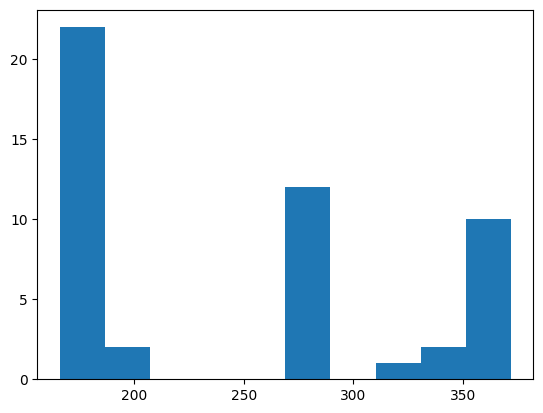

In [167]:
plt.hist(photo_sum)

In [116]:
dtrigger = np.diff(trigger)
_, sdtrigger = trigger_to_event_v1_1(dtrigger)
fig, ax= plt.subplots(1, 1, figsize=(15, 3))
ax.plot(trigger);
ax.plot(dtrigger);
# ax.plot(sdtrigger);
ax.set_xlim(5800, 12000)

ValueError: too many values to unpack (expected 2, got 165935)

In [ ]:
for i in range(len(trigger)):
    

In [92]:
def trigger_to_event_v1_1(trigger, window_size=500):
    """
    Parse a photodiode trigger signal to detect motor and rest events.

    This function scans a binary photomark signal and identifies events
    based on the magnitude of fluctuations within a sliding window. 
    It returns an array of the same length as the input trigger, where
    each element indicates the type of event at that time.

    Parameters
    ----------
    trigger : array-like
        Binary (0 or 1) signal from a photodiode, representing stimulus fluctuations.
    window_size : int, optional, default=600
        Number of samples to consider in the sliding window when detecting changes.

    Returns
    -------
    events : array-like
        Array of the same length as `trigger`, containing:
        - 0 : no event
        - 1 : motor event
        - 2 : rest event
    trigger_sum : array-like
        Array of the same length as `trigger`, 
        containing sum of its elements in window_size. 
    """

    events = np.zeros(len(trigger)) 
    
    n_motor = 0
    wait_start = True
    idx_trial_start = None
    idx_rest = None
    trigger_sum = []
    pr_v = 0
    for start_idx in range(len(trigger)):
        how_much_left = len(trigger) - window_size
        end_idx = start_idx + window_size if window_size < how_much_left else start_idx + how_much_left
        tsum = np.sum(trigger[start_idx:end_idx])
        trigger_sum.append(tsum)

        tsummax = max(trigger_sum[-window_size:])                   # max value for the last window_size ms
        if (pr_v == tsummax) & (tsum < pr_v):                       # if new value is smaller than previous
            if wait_start:                                         # two  bursts  -> signal of a beginning 
                wait_start = False
                idx_trial_start = start_idx
            elif not(wait_start) and (n_motor < 4):                # three bursts -> signal of a motor trial 
                n_motor += 1
                if n_motor == 4:
                    events[idx_trial_start:start_idx] = 1
                    idx_rest = start_idx
            elif not(wait_start) and (n_motor == 4):               # four bursts -> signal of a rest trial
                events[idx_rest:start_idx] = 2
                n_motor = 0
                wait_start = True

        pr_v =  tsum
    
    return events, np.asarray(trigger_sum) 

In [95]:
events, sum = trigger_to_event_v1_1(trigger)

(5000.0, 12000.0)

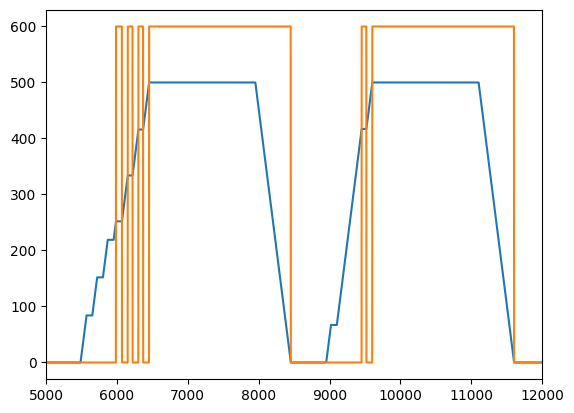

In [100]:
plt.plot(sum)
plt.plot(trigger * 600)
plt.xlim(5000, 12000)

(0.0, 25000.0)

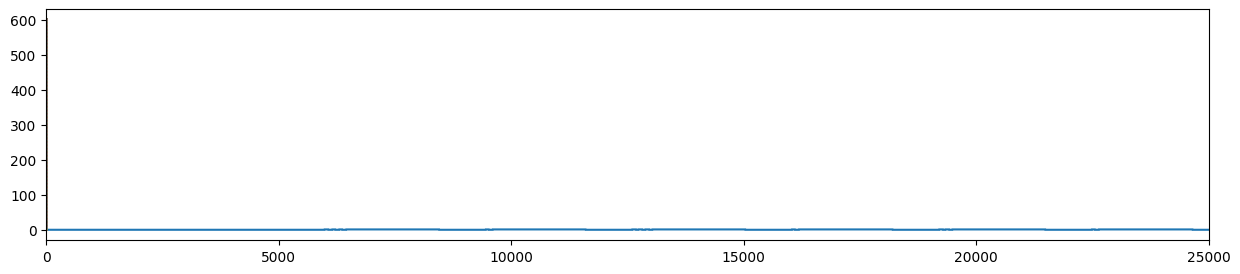

In [ ]:
fig, ax= plt.subplots(1, 1, figsize=(15, 3))
ax.plot(trigger);
ax.plot(events)
ax.set_xlim(0, 25000)

In [101]:
import numpy as np
from typing import Tuple
def find_events_by_transitions(arr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Преобразует массив из 0 и 1 в три массива событий разных типов.
    
    Parameters:
    -----------
    arr : np.ndarray
        Входной массив из 0 и 1
        
    Returns:
    --------
    tuple[np.ndarray, np.ndarray, np.ndarray]
        Три массива размерности (n_events, 2) для событий с 1, 2 и 3 переходами
        Каждый массив содержит пары [start, end] - индексы начала и конца промежутка с единицами
    """
    
    # Находим все переходы
    transitions = np.diff(arr)
    starts = np.where(transitions == 1)[0] + 1  # моменты перехода 0→1 (индексы начала ивентов)
    ends = np.where(transitions == -1)[0] + 1   # моменты перехода 1→0 (индексы конца ивентов)
    
    # Если массив начинается с 1, добавляем начало в 0
    if arr[0] == 1:
        starts = np.insert(starts, 0, 0)
    # Если массив заканчивается 1, добавляем конец в len(arr)
    if arr[-1] == 1:
        ends = np.append(ends, len(arr))
    
    # Проверяем, что количество начал и концов совпадает
    assert len(starts) == len(ends), "Количество начал и концов не совпадает"
    
    events_type1 = []  # после 1 перехода
    events_type2 = []  # после 2 переходов  
    events_type3 = []  # после 3 переходов
    
    for i in range(len(starts)):
        # Считаем количество переходов 0→1 до текущего ивента
        transition_count = 1  # текущий переход
        
        # Смотрим предыдущие ивенты, пока между ними есть только нули
        j = i - 1
        while j >= 0:
            # Проверяем, что между ивентом j и ивентом i только нули
            if ends[j] < starts[i]:  # есть промежуток
                # Проверяем, что весь промежуток состоит из нулей
                if np.all(arr[ends[j]:starts[i]] == 0):
                    transition_count += 1
                    j -= 1
                else:
                    break
            else:
                break
        
        # Определяем тип по количеству переходов
        if transition_count == 1:
            events_type1.append([starts[i], ends[i]])
        elif transition_count == 2:
            events_type2.append([starts[i], ends[i]])
        elif transition_count >= 3:
            events_type3.append([starts[i], ends[i]])
    
    # Преобразуем в numpy массивы
    type1 = np.array(events_type1) if events_type1 else np.empty((0, 2), dtype=int)
    type2 = np.array(events_type2) if events_type2 else np.empty((0, 2), dtype=int)
    type3 = np.array(events_type3) if events_type3 else np.empty((0, 2), dtype=int)
    
    return type1, type2, type3

In [102]:
idxs1, idxs2, idxs3 = find_events_by_transitions(trigger)

In [104]:
idxs1

array([[5986, 6070]])

In [52]:
trigger

array([0, 0, 0, ..., 0, 0, 0], shape=(165936,))